<h1>Clasificacion por Máquina de Soporte Vectorial en microprocesador 64 bits vb.net</h1>

In [2]:
from sklearn import svm

import seaborn as sns
import matplotlib.pyplot as plt

import pandas as pd

from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import log_loss
from sklearn.metrics import recall_score
import statistics

from sklearn.model_selection import train_test_split#para seleccionar lotes de entrenamiento y prueba
# documentacion en: https://scikit-learn.org/stable/modules/svm.html#classification
from sklearn.model_selection import GridSearchCV, cross_val_score

from sklearn.metrics import cohen_kappa_score
from sklearn import preprocessing
from keras.utils import np_utils


from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import SelectKBest # para seleccionar las mejores caracteristicas
from sklearn.feature_selection import chi2, f_regression
from sklearn.preprocessing import MinMaxScaler

from numpy import array
import pandas as pd
import numpy as np

from sklearn import preprocessing

import optuna

<h1>0. Funciones</h1>

In [3]:
def matriz_de_confusion(clases_reales, clases_predichas, titulo):
    """ Visualiza la matriz de confusión """
   
    matriz = confusion_matrix(clases_reales, clases_predichas)
    accuracy = accuracy_score(clases_reales, clases_predichas)
    maximo_valor=np.max(matriz);
    #print(maximo_valor);
    #Código de matplotlib para graficar 
    plt.figure(figsize=(6, 6))
    matriz = pd.DataFrame(matriz,columns=["0 : Normal", "1 : Caudaloso","2 : Impacto piedras"])
    plt.matshow(matriz, cmap="summer", vmin=0, vmax=maximo_valor, fignum=1)
    plt.colorbar()
    plt.xticks(range(len(matriz.columns)), matriz.columns, rotation=45)
    plt.yticks(range(len(matriz.columns)), matriz.columns)
    #etiquetas = (("Verdaderos\nnegativos", "Falsos\npositivos"),
    #             ("Falsos\nnegativos", "Verdaderos\npositivos"))
    etiquetas = (("Verdad", "Falso","Falso"),
                ("Falso", "Verdad","Falso"),
                ("Falso", "Falso","Verdad"))
    
    plt.text(3.20, -0.30, titulo, fontsize=14, c="blue")
    plt.text(3.20, -0.10, "Exactitud: %0.2f" % accuracy, fontsize=14)
    for i in range(len(matriz.columns)):
        for j in range(len(matriz.columns)):
            plt.text(i, j + 0.14, str(matriz.iloc[j, i]),
                     fontsize=30, ha="center", va="center")
            plt.text(i, j - 0.25, etiquetas[i][j],
                     fontsize=11.5, ha="center", va="center")           
    plt.show()

In [4]:
def geometric_mean_score(y_true, y_pred):
    recalls = recall_score(y_true, y_pred, average=None); # recall por clase
    gmean = np.prod(recalls) ** (1.0 / len(recalls));   # raíz cúbica si hay 3 clases
    return gmean

In [18]:
def calcular_metricas(y_true, y_pred,num_evaluacion):
    metricas_reg1 = np.zeros((1,19));
    metricas_reg1[0,0]=num_evaluacion+1;
    metricas_reg1[0,1]=0;
    #1. Accuracy
    accuracy_valor=accuracy_score(clase_test, clase_prediccion);
    print(f"\nAccuracy: {accuracy_valor:.3f}");
    metricas_reg1[0,2]="{:.3f}".format(accuracy_valor);
    #En la clasificación de múltiples etiquetas, esta función calcula la precisión del subconjunto: 
    #el conjunto de etiquetas predicho para una muestra debe coincidir exactamente con el conjunto 
    #de etiquetas correspondiente en y_true
    
    #2. Loss
    loss=1-accuracy_valor;
    print(f"\nLoss: {loss:.3f}");
    metricas_reg1[0,3]="{:.3f}".format(loss);
    
    #3. F1 score
    f1_per_clase = f1_score(clase_test, clase_prediccion,average=None)
    print(f"\nf1_per_clase: {f1_per_clase[0]:.3f} {f1_per_clase[1]:.3f} {f1_per_clase[2]:.3f}");
    metricas_reg1[0,11]="{:.3f}".format(f1_per_clase[0]);metricas_reg1[0,12]="{:.3f}".format(f1_per_clase[1]);
    metricas_reg1[0,13]="{:.3f}".format(f1_per_clase[2]);
        
    #4. Balanced accuracy
    #La precisión equilibrada en problemas de clasificación binaria y multiclase para abordar conjuntos 
    #de datos desequilibrados. Se define como el promedio de recuperación obtenido en cada clase.
    #El mejor valor es 1 y el peor valor es 0 cuando el ajuste es falso.
    balanceado_acuracy=balanced_accuracy_score(clase_test, clase_prediccion);
    print(f"\nbalanceado accuracy: {balanceado_acuracy:.3f}");
    metricas_reg1[0,10]="{:.3f}".format(balanceado_acuracy);
    
    #5. Recall
    confusion_basi = confusion_matrix(clase_test, clase_prediccion)
    sensitivity =recall_score(clase_test, clase_prediccion, average=None);
    recall_normal=confusion_basi[0,0]/(confusion_basi[0,0]+confusion_basi[0,1]+confusion_basi[0,2]);#precision=vp1/(vp1+fp1+fp1)
    recall_cauda=confusion_basi[1,1]/(confusion_basi[1,0]+confusion_basi[1,1]+confusion_basi[1,2]);#precision=vp1/(vp1+fp1+fp1)
    recall_piedra=confusion_basi[2,2]/(confusion_basi[2,0]+confusion_basi[2,1]+confusion_basi[2,2]);#precision=vp1/(vp1+fp1+fp1)
    print(f"\nRecall nor-cau-pie:{recall_normal:.3f} {recall_cauda:.3f} {recall_piedra:.3f}");
    metricas_reg1[0,7]="{:.3f}".format(recall_normal);metricas_reg1[0,8]="{:.3f}".format(recall_cauda);
    metricas_reg1[0,9]="{:.3f}".format(recall_piedra);
    
    #6. presicion
    confusion_basi = confusion_matrix(clase_test, clase_prediccion)
    print(confusion_basi);
    presicion_normal=confusion_basi[0,0]/(confusion_basi[0,0]+confusion_basi[1,0]+confusion_basi[2,0]);#precision=vp1/(vp1+fp1+fp1)
    presicion_cauda=confusion_basi[1,1]/(confusion_basi[0,1]+confusion_basi[1,1]+confusion_basi[2,1]);#precision=vp1/(vp1+fp1+fp1)
    presicion_piedra=confusion_basi[2,2]/(confusion_basi[0,2]+confusion_basi[1,2]+confusion_basi[2,2]);#precision=vp1/(vp1+fp1+fp1)
    print(f"\nPresición nor-cau-pie:{presicion_normal:.3f} {presicion_cauda:.3f} {presicion_piedra:.3f}");
    metricas_reg1[0,4]="{:.3f}".format(presicion_normal);metricas_reg1[0,5]="{:.3f}".format(presicion_cauda);
    metricas_reg1[0,6]="{:.3f}".format(presicion_piedra);
    
    #specificity = tn / (tn + fp) #Verdaderos Positivos(TP)  --- Falsos Negativos(FN)
    specifi_normal=(confusion_basi[0,1]+confusion_basi[0,2])/(confusion_basi[0,0]+confusion_basi[0,1]+confusion_basi[0,2]);#precision=vp1/(vp1+fp1+fp1)
    specifi_cauda=(confusion_basi[1,0]+confusion_basi[1,2])/(confusion_basi[1,0]+confusion_basi[1,1]+confusion_basi[1,2]);#precision=vp1/(vp1+fp1+fp1)
    specifi_piedra=(confusion_basi[2,0]+confusion_basi[2,1])/(confusion_basi[2,0]+confusion_basi[2,1]+confusion_basi[2,2]);#precision=vp1/(vp1+fp1+fp1)
    print(f"\nSpecificity nor-cau-pie:{specifi_normal:.3f} {specifi_cauda:.3f} {specifi_piedra:.3f}");
    metricas_reg1[0,16]="{:.3f}".format(specifi_normal);metricas_reg1[0,17]="{:.3f}".format(specifi_cauda);
    metricas_reg1[0,18]="{:.3f}".format(specifi_piedra);
    
    #7. Calculate G-Mean
    media_geometrica=geometric_mean_score(clase_test, clase_prediccion);
    print(f"\nG-Mean:{media_geometrica:.3f}");
    metricas_reg1[0,15]="{:.3f}".format(media_geometrica);
    
    #8. Kappa
    kappa=cohen_kappa_score(clase_test, clase_prediccion); #cohen_kappa_score
    print(f"\nCohen’s kappa:{kappa:.3f}");
    metricas_reg1[0,14]="{:.3f}".format(kappa);
    
    return   metricas_reg1;

In [6]:
metricas_reg0 = np.zeros((1,19));
metricas_tabla= np.zeros((5,19));
# las dos líneas siguientes para validar las caracteristicas propuestas
col_caract=78;# 3 al 78 (75 caracteristicass)  si desea incluir las tres propuestas
col_caract=75;# 3 al 78 (72 caracteristicass)  si no desea incluir las tres propuestas
#; 32 luego del 2 al 32(30 caracteristicas)
# 51, 2 al 51 (49 caracteristicas, incluye la propuesta)  
parametros = []
entro_geni="entropy";  # gini    o    entropy

<h2>1. Clases</h2>

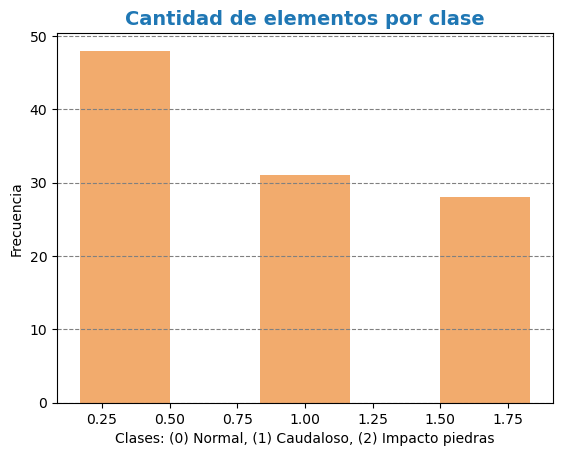

In [8]:
df = pd.read_csv('features_16agos2026_sismos_audio_unificado_csv.csv')
df.head(10) #muestra las 10 primeras filas

caracteristicas0= df.to_numpy();
caracteristicas1= caracteristicas0[:,3:col_caract];
clase= caracteristicas0[:,2];


plt.hist(clase, bins=3, color='#F2AB6D', rwidth=0.5)
plt.xlabel('Clases: (0) Normal, (1) Caudaloso, (2) Impacto piedras')
plt.ylabel('Frecuencia')
plt.title('Cantidad de elementos por clase', loc = "center", fontdict = {'fontsize':14, 'fontweight':'bold', 'color':'tab:blue'});
plt.grid(axis = 'y', color = 'gray', linestyle = 'dashed');
plt.show()

<h2>2. Análisis de componenets principales</h2>

Varianza explicada por cada componente: [1.81909833e+05 4.62296137e+04 1.91393443e+04 5.56286518e+03
 6.61550109e+02 3.04460122e+02 1.82004486e+02 1.26284570e+02
 9.77871524e+01 8.03915965e+01 6.32109390e+01 5.60794499e+01
 3.53179466e+01 2.20811044e+01 1.78454631e+01 1.30824136e+01
 1.11120572e+01 6.14520152e+00 4.09252079e+00 3.13044176e+00
 2.70903451e+00 2.14981001e+00 1.74482858e+00 1.62810212e+00
 1.34723123e+00 1.19261786e+00 1.09015098e+00 9.17135227e-01
 7.94141049e-01 7.05838456e-01 6.58069472e-01 5.46748748e-01
 5.07630944e-01 4.07541777e-01 3.89571240e-01 3.43972900e-01
 3.14627154e-01 2.66105341e-01 2.02122046e-01 1.73351564e-01
 1.59134360e-01 1.53440188e-01 1.35200443e-01 1.32080379e-01
 1.19495689e-01 7.42346733e-02 5.44910566e-02 3.88962731e-02
 3.09998595e-02 1.96730940e-02 9.25869798e-03 8.02529774e-03
 3.65492613e-03 2.72962706e-03 1.85017461e-03 1.15850582e-03
 4.21040315e-04 3.48426633e-04 2.57055414e-04 1.56872365e-04
 7.63964847e-05 5.93325223e-05 3.81357155e-05

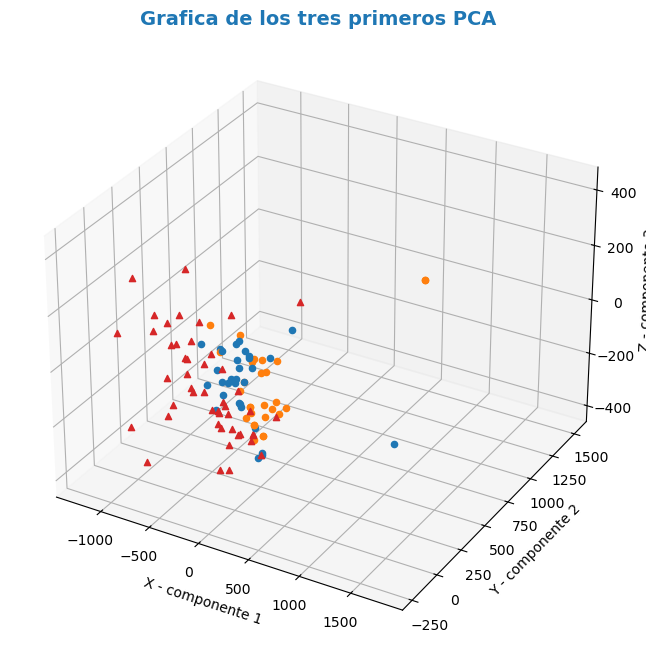

In [9]:
#_______________________lo siguiente para el análisis de componentes principales______________
from sklearn.decomposition import PCA
pca=PCA()
df3 = pd.DataFrame(caracteristicas0[:,3:col_caract]) #convertir matriz numpy en Dataframe
resultados_pca=pca.fit_transform(df3);

#print('Matriz valores proyectados con los PCA de matriz de 20 caracteristicas:');
#print(resultados_pca);
print('Varianza explicada por cada componente:', pca.explained_variance_);
print('Proporción de la varianza explicada por cada componente:', pca.explained_variance_ratio_);
# la suma de los tres primeros componentes de pca.explained_variance_ratio_ debe generar un valor cercano al 100%

#ahora se grafican los PCA en plano 3d
fig = plt.figure(figsize=(12,8)) # Set the figure size to 8 inches wide-ancho and 6 inches tall -alto
ax = fig.add_subplot(projection='3d')
cant_filas=len(resultados_pca);
tipo_avenida=caracteristicas0[:,2];
print(tipo_avenida);
elemento_clase_norm=0;elemento_clase_caud=0;elemento_clase_pied=0;
for i in range(cant_filas):
    if (tipo_avenida[i]==0):
        elemento_clase_norm=elemento_clase_norm+1;
    if (tipo_avenida[i]==1):
        elemento_clase_caud=elemento_clase_caud+1;
    if (tipo_avenida[i]==2):
        elemento_clase_pied=elemento_clase_pied+1;
for i in range(cant_filas):
    xs = resultados_pca[i,0];
    ys = resultados_pca[i,1];
    zs = resultados_pca[i,2];
    if (tipo_avenida[i]==0):         # antes:  if (i<=elemento_clase_no_aven):
        ax.scatter(xs, ys, zs, marker='^', color = 'tab:red')
    if (tipo_avenida[i]==1):
        ax.scatter(xs, ys, zs, marker='o', color = 'tab:blue')
    if (tipo_avenida[i]==2):
        ax.scatter(xs, ys, zs, marker='o', color = 'tab:orange')
        
ax.set_xlabel('X - componente 1');
ax.set_ylabel('Y - componente 2');
ax.set_zlabel('Z - componente 3');
plt.title('Grafica de los tres primeros PCA', loc = "center", fontdict = {'fontsize':14, 'fontweight':'bold', 'color':'tab:blue'});

#for angle in range(0, 360):
#        ax.view_init(elev=30, azim=angle) # Rotate around azimuth, fixed elevation
#        plt.draw()
#        plt.pause(.001) # Pause briefly to see the animation
plt.show()

#_________________________guardar archivo________________________________
# Grabar la informacion a un archivo
para_guardar = pd.DataFrame(resultados_pca);
#para_guardar.to_csv('5_PCA_1836udios_enero2025.csv',header = True, index = False)

<h1>PARTE 1 - TODAS LAS CARACTERÍSTICAS Y SE ESCOGEN LAS MEJORES</h2>

<h2>3. Aplicación de SVM desde Sklearn con optimizacion de parametros</h2>

<h3>3.1 Selección de las 8 mejores características con SelectKBest</h3>

Aplicando una funcion que selecciona las cuatro mejores caracteristicas
-------preprocesando--------
LabelEncoder()
[0 1 2]
Después de seleccionar, las cuatro mejores caracteristicas son: (107, 12)
[[0.42100071 0.60507591 0.51538592 ... 1.         0.         0.        ]
 [0.37119393 0.50646564 0.56343868 ... 0.85714286 0.14285714 0.        ]
 [0.73358185 0.497141   0.57214385 ... 1.         0.         0.        ]
 ...
 [0.14307744 0.02839476 0.04759106 ... 0.42857143 0.         0.66666667]
 [0.13266455 0.27129976 0.31905765 ... 0.71428571 0.         0.33333333]
 [0.10379696 0.         0.00566517 ... 0.42857143 0.         0.66666667]]

Todas las caracteristicas(72 hasta el momento):
['c1' 'c2' 'c3' 'c4' 'c5' 'c6' 'c7' 'c8' 'c9' 'c10' 'c11' 'c12' 'c13'
 'c14' 'c15' 'c16' 'c17' 'c18' 'c19' 'c20' 'c21' 'c22' 'c23' 'c24' 'c25'
 'c26' 'c27' 'c28' 'c29' 'c30' 'c31' 'c32' 'c33' 'c34' 'c35' 'c36' 'c37'
 'c38' 'c39' 'c40' 'c41' 'c42' 'c43' 'c44' 'c45' 'c46' 'c47' 'c48' 'c49'
 'c50' 'c51' 'c52' '

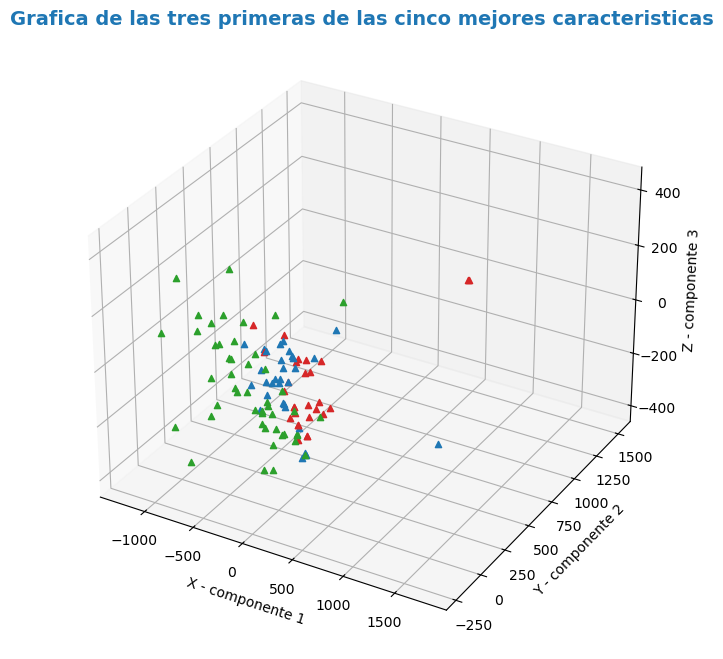

In [10]:
col_caract=78;# 3 al 78 (75 caracteristicass)  si desea incluir las tres propuestas
#col_caract=75;# 3 al 78 (72 caracteristicass)  si no desea incluir las tres propuestas
#; 32 luego del 2 al 32(30 caracteristicas)
# 51, 2 al 51 (49 caracteristicas, incluye la propuesta)  

print("Aplicando una funcion que selecciona las cuatro mejores caracteristicas");
df = pd.read_csv('features_16agos2026_sismos_audio_unificado_csv.csv')
df.head(10) #muestra las 10 primeras filas

caracteristicas0= df.to_numpy();
caracteristicas1= caracteristicas0[:,3:col_caract];
clase= caracteristicas0[:,2];
print('-------preprocesando--------');
le = preprocessing.LabelEncoder();
le.fit(clase);
print(le);
print(le.classes_);
clase=le.transform(clase); #con esto se tranforman las etiquetas de numeros a categorias

select = SelectKBest(score_func=chi2, k=12)
# scale the data to be between 0 and 1,  ya que chi2 solo soporta valores positivos
sc = MinMaxScaler()
caracteristicas_normal_pos = sc.fit_transform(caracteristicas1)
z_mejores_caract = select.fit_transform(caracteristicas_normal_pos,clase) #caracteristicas, clase
print("Después de seleccionar, las cuatro mejores caracteristicas son:", z_mejores_caract.shape) 

print(z_mejores_caract);
filter = select.get_support()
# si agrega otras caracteristicas esto debe cambiar
# lo siguiente si desea las 3 características propuestas

features0=['c1','c2','c3','c4','c5','c6','c7','c8','c9','c10','c11','c12','c13','c14','c15','c16','c17','c18','c19','c20','c21','c22',
           'c23','c24','c25','c26','c27','c28','c29','c30','c31','c32','c33','c34','c35','c36','c37','c38','c39','c40','c41','c42','c43','c44',
         'c45','c46','c47','c48','c49','c50','c51','c52','c53','c54','c55','c56','c57','c58','c59','c60','c61','c62','c63','c64',
          'c65','c66','c67','c68','c69','c70','c71','c72','c73','c74','c75'];
# lo siguiente si no desea las características propuestas
#features0=['c1','c2','c3','c4','c5','c6','c7','c8','c9','c10','c11','c12','c13','c14','c15','c16','c17','c18','c19','c20','c21','c22',
#           'c23','c24','c25','c26','c27','c28','c29','c30','c31','c32','c33','c34','c35','c36','c37','c38','c39','c40','c41','c42','c43','c44',
#         'c45','c46','c47','c48','c49','c50','c51','c52','c53','c54','c55','c56','c57','c58','c59','c60','c61','c62','c63','c64',
#          'c65','c66','c67','c68','c69','c70','c71','c72'];
features=array(features0);
print();
print("Todas las caracteristicas(72 hasta el momento):")
print(features)
print();

print("Las mejores selecionadas:");
print(features[filter]);
print();
#print(z_mejores_caract); 
print();

print("Se grafican las mejores características:");
#ahora se grafican los PCA en plano 3d
fig = plt.figure(figsize=(12,8)) # Set the figure size to 8 inches wide-ancho and 6 inches tall -alto
ax = fig.add_subplot(projection='3d')
cant_filas=len(z_mejores_caract); #--
tipo_avenida=caracteristicas0[:,2];

elemento_clase_normal=0;
elemento_clase_caudaloso=0;
elemento_clase_impacto=0;
for i in range(cant_filas):
    if (tipo_avenida[i]==0):
        elemento_clase_normal=elemento_clase_normal+1;
    if (tipo_avenida[i]==1):
        elemento_clase_caudaloso=elemento_clase_caudaloso+1;
    if (tipo_avenida[i]==2):
        elemento_clase_impacto=elemento_clase_impacto+1;
for i in range(cant_filas):
    xs = resultados_pca[i,0];
    ys = resultados_pca[i,1];
    zs = resultados_pca[i,2];
    if (tipo_avenida[i]==0):
        ax.scatter(xs, ys, zs, marker='^', color = 'tab:green')
    if (tipo_avenida[i]==1):
        ax.scatter(xs, ys, zs, marker='^', color = 'tab:blue')
    if (tipo_avenida[i]==2):
       ax.scatter(xs, ys, zs, marker='^', color = 'tab:red')
        
ax.set_xlabel('X - componente 1');
ax.set_ylabel('Y - componente 2');
ax.set_zlabel('Z - componente 3');
plt.title('Grafica de las tres primeras de las cinco mejores caracteristicas', loc = "center", fontdict = {'fontsize':14, 'fontweight':'bold', 'color':'tab:blue'});
plt.show()

<h3>3.2 Selección de los mejores hiperparámetros SVM</h3>

In [11]:
    x=z_mejores_caract;
    print('-------preprocesando--------');
    le = preprocessing.LabelEncoder();
    le.fit(clase);
    print(le);
    print(le.classes_);
    y=le.transform(clase); #con esto se tranforman las etiquetas de numeros a categorias
    
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=23)

-------preprocesando--------
LabelEncoder()
[0 1 2]


In [12]:
def objective(trial):
       # Definition of space search
       C = trial.suggest_float("C", 1e-10, 1e10, log=True)
       gamma = trial.suggest_float("gamma", 1e-10, 1e10, log=True)
       kernel = trial.suggest_categorical("kernel", ["linear", "rbf", "poly"])
        
       # Classifier definition
       # Crear el modelo SVM con los parámetros sugeridos
       model = SVC(C=C, gamma=gamma, kernel=kernel)
    
       # Evaluar el modelo usando Validación Cruzada
       score = cross_val_score(model, x_train, y_train, n_jobs=-1, cv=3).mean()
    
       return score

In [13]:
    # 2. Crear un estudio de Optuna y especificar la dirección (maximizar la precisión)
    study = optuna.create_study(direction='maximize')

    # 3. Ejecutar la optimización
    # Recevies the function to be optimized and the number of trials
    study.optimize(objective, n_trials=500) #estaba en n_trials=20

[I 2026-08-18 18:07:26,338] A new study created in memory with name: no-name-a7983f8c-77c0-4978-b03d-81c3079c3bfe
[I 2026-08-18 18:07:31,788] Trial 0 finished with value: 0.9194444444444444 and parameters: {'C': 1961.1784553434786, 'gamma': 124.30153685277065, 'kernel': 'linear'}. Best is trial 0 with value: 0.9194444444444444.
[I 2026-08-18 18:07:33,105] Trial 1 finished with value: 0.9049999999999999 and parameters: {'C': 1.2862072683716301, 'gamma': 200.16994797445432, 'kernel': 'linear'}. Best is trial 0 with value: 0.9194444444444444.
[I 2026-08-18 18:07:33,126] Trial 2 finished with value: 0.4594444444444444 and parameters: {'C': 0.029147767439649887, 'gamma': 0.0014733315383386046, 'kernel': 'rbf'}. Best is trial 0 with value: 0.9194444444444444.
[I 2026-08-18 18:07:33,151] Trial 3 finished with value: 0.4594444444444444 and parameters: {'C': 4.440138301195365e-10, 'gamma': 0.0011290298753800659, 'kernel': 'linear'}. Best is trial 0 with value: 0.9194444444444444.
[I 2026-08-18 

In [14]:
# 4. Resultados
    
print(f"Número de ensayos terminados: {len(study.trials)}")
print(f"Best average accuracy: {study.best_value}")
print(f"Best parameters: {study.best_params}")
mejores_parametros=study.best_params
optimal_model=SVC(**mejores_parametros)
optimal_model.fit(x_train, y_train);
# Trains a model with the optimal parameters
#optimal_model = modelOpt.train_optimal_configuration(study.best_params)

#Print final results
print(f"Test score: {optimal_model.score(x_test, y_test)}")
print(f"Train score: {optimal_model.score(x_train, y_train)}")

Número de ensayos terminados: 500
Best average accuracy: 0.9466666666666667
Best parameters: {'C': 3.349166564069412e-08, 'gamma': 383.8352286241568, 'kernel': 'poly'}
Test score: 1.0
Train score: 0.9864864864864865


<h3>3.3 Aplicación del SVM con las 5 mejores características</h3>

---------clasificacion SVM mejores caract - sobre el lote de test--------
La precición de la predicción es:  100.0 %

Accuracy: 1.000

Loss: 0.000

f1_per_clase: 1.000 1.000 1.000

balanceado accuracy: 1.000

Recall nor-cau-pie:1.000 1.000 1.000
[[14  0  0]
 [ 0  8  0]
 [ 0  0 11]]

Presición nor-cau-pie:1.000 1.000 1.000

Specificity nor-cau-pie:0.000 0.000 0.000

G-Mean:1.000

Cohen’s kappa:1.000


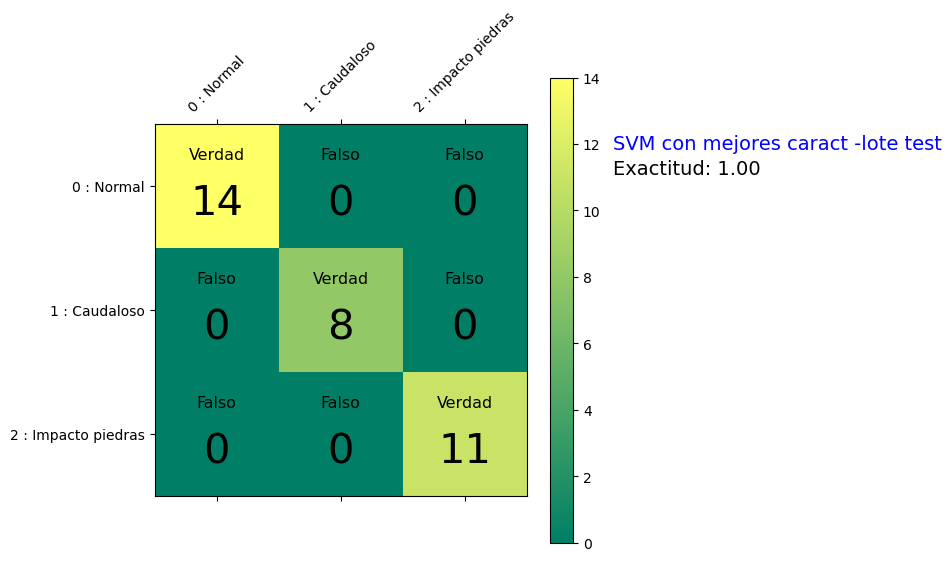

Indice Kappa SVM con  mejores caracteristicas -lote test: 1.0
--------clasificacion SVM mejores caract - sobre la totalidad de las observaciones-------
La precición de la predicción es:  99.06542056074767 %


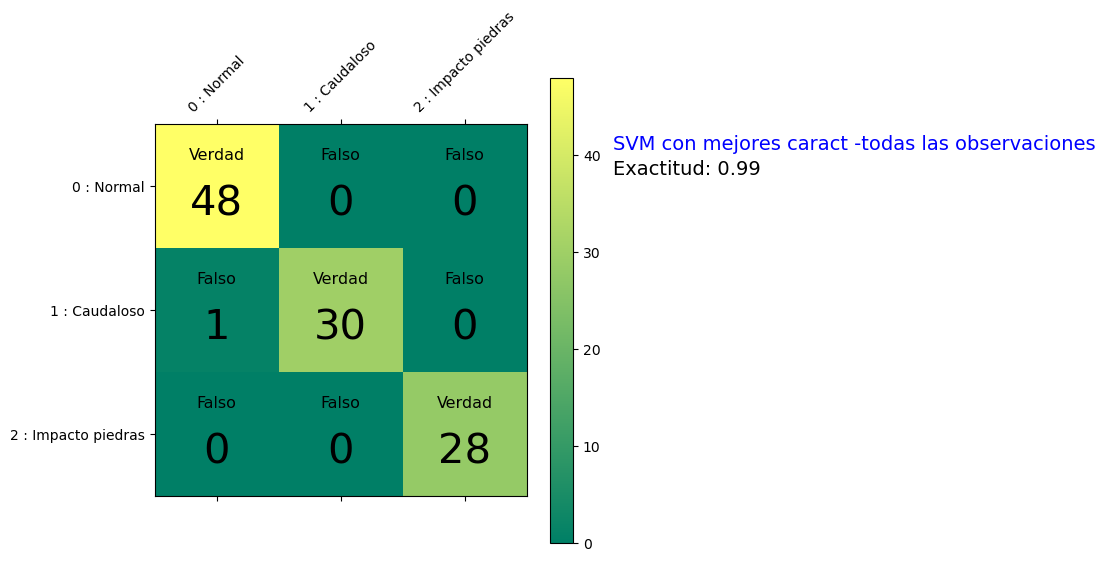

Indice Kappa SVM con mejores caract -todas las observaciones: 0.9855072463768116


In [19]:
# --- Una vez ajustado el modelo se puede utilizar para predecir nuevos valores.
print('---------clasificacion SVM mejores caract - sobre el lote de test--------');
clase_prediccion=optimal_model.predict(x_test);
print("La precición de la predicción es: ",optimal_model.score(x_test, y_test)*100,"%");
clase_test=y_test;
metricas_reg0=calcular_metricas(clase_test, clase_prediccion,2);
metricas_tabla=np.insert(metricas_tabla, 2, metricas_reg0, axis=0);#debe inciar desde 0 y luego se incrementa
parametros.append("4 carac,200 árboles");
matriz_de_confusion(y_test, clase_prediccion, "SVM con mejores caract -lote test") 
kappa1=cohen_kappa_score(y_test, clase_prediccion);
print('Indice Kappa SVM con  mejores caracteristicas -lote test:',kappa1);

print('--------clasificacion SVM mejores caract - sobre la totalidad de las observaciones-------');
clase_prediccion=optimal_model.predict(x);
print("La precición de la predicción es: ",optimal_model.score(x, y)*100,"%");
matriz_de_confusion(y, clase_prediccion, "SVM con mejores caract -todas las observaciones") 
kappa1=cohen_kappa_score(y, clase_prediccion);
print('Indice Kappa SVM con mejores caract -todas las observaciones:',kappa1);

In [20]:
# OPCIÓN A: Imprimir el objeto (muestra la configuración al crearlo)
print(optimal_model)

# OPCIÓN B: Obtener un diccionario con todos los parámetros
params = optimal_model.get_params()
print(params)

SVC(C=3.349166564069412e-08, gamma=383.8352286241568, kernel='poly')
{'C': 3.349166564069412e-08, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 383.8352286241568, 'kernel': 'poly', 'max_iter': -1, 'probability': False, 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}


In [21]:
import m2cgen as m2c
code = m2c.export_to_c(optimal_model) 
#bosque_aleatorio6_estim50_depth6_mfsqrt_10bestfeat_abr2026
#bosque_aleatorio7_estim10_depth6_mflog2_10bestfeat_abr2026
print(code)
with open("codigo_exportado_svm_ago16_pc77carct.txt", "w") as archivo:
    print(code, file=archivo)

#include <math.h>
#include <string.h>
void score(double * input, double * output) {
    double var0;
    var0 = pow(383.8352286241568 * (0.08770559419169906 * input[0] + 0.6173287354289532 * input[1] + 0.8899243046039493 * input[2] + 0.4075574994103794 * input[3] + 0.1863773663928741 * input[4] + 0.03785833294707901 * input[5] + 0.005899700288878819 * input[6] + 0.8178748835499217 * input[7] + 0.09585132100575322 * input[8] + 0.7142857142857142 * input[9] + 0.2857142857142857 * input[10] + 0.0 * input[11]) + 0.0, 3.0);
    double var1;
    var1 = pow(383.8352286241568 * (0.13818460760120976 * input[0] + 0.6462782927744337 * input[1] + 0.6252971809261805 * input[2] + 0.5906060108222159 * input[3] + 0.030115975569751582 * input[4] + 0.003718431321375254 * input[5] + 0.0008508686210529554 * input[6] + 0.5880323546251105 * input[7] + 0.11422389802480293 * input[8] + 0.8571428571428571 * input[9] + 0.14285714285714285 * input[10] + 0.0 * input[11]) + 0.0, 3.0);
    double var2;
    var2 = p

In [22]:
import pickle #guardar modelo en disco duro
pickle.dump(optimal_model, open('modelo_svm_16agos2026_pc_sonido_micros_75c.sav', 'wb'))

In [24]:
#-----------------------------probar con un registro--------------------
a1 = (11.46085422 - 0.06928221) / 13.09301;
a2 = (11.54515006 - 0.04005357) / 11.623893;
a3 = (10.76516264 - 0.03224902) / 10.2334602;
a4 = (7.666889848- 0.04671299) / 9.41713302;
a5 = (9.700817087 - 0.02516089) / 9.16040029;
a6 = (9.105169976 - 0.01363393) / 8.65279119;
a7 = (1 - 0) / 7;
a8 = (0 - 0) / 7;
#..... debe incrementar caracteristicas en la siguiente línea, según entradas
#probar=[[a1,a2,a3,a4,a5,a6,a7,a8]];

#prediccion =optimal_model.predict(probar)

#print("El resultado es:", prediccion[0])
#print("El vector prueba sin normalizar es:", probar )
#print(x_test);


<h1>Parte 2  - Elegir mejores características por cada tipo de señal</h1>

<H2>4.1 Mejores características del sonido</H2>

In [26]:
num_mejor_carac=3;
total_caract=28;
print("Aplicando una funcion que selecciona las", num_mejor_carac ," mejores caracteristicas");
df = pd.read_csv('features_16agos2026_sismos_audio_unificado_csv.csv')
df.head(10) #muestra las 10 primeras filas

caracteristicas0= df.to_numpy();
caracteristicas1= caracteristicas0[:,3:48]; #la tercera posicion tiene la primer característica y se extiende hasta la columna (48-1)
# la columna sub0 tiene el experimento
clase= caracteristicas0[:,num_mejor_carac]; # la segunda columna tiene la clase
print('-------preprocesando--------');
le = preprocessing.LabelEncoder();
le.fit(clase);
print(le);
print(le.classes_);
clase=le.transform(clase); #con esto se tranforman las etiquetas de numeros a categorias

select = SelectKBest(score_func=chi2, k=num_mejor_carac)
# scale the data to be between 0 and 1,  ya que chi2 solo soporta valores positivos
sc = MinMaxScaler()
caracteristicas_normal_pos = sc.fit_transform(caracteristicas1)
z_mejores_caract = select.fit_transform(caracteristicas_normal_pos,clase) #caracteristicas, clase
print("Después de seleccionar, las ",num_mejor_carac," mejores caracteristicas, la matriz es de:", z_mejores_caract.shape) 

#print(z_mejores_caract);

filter = select.get_support()
# si agrega otras caracteristicas esto debe cambiar
#features0=['c1','c2','c3','c4','c5','c6','c7','c8','c9','c10','c11','c12','c13','c14','c15','c16','c17','c18','c19','c20','c21','c22',
#           'c23','c24','c25','c26','c27','c28','c29','c30','c31','c32','c33','c34','c35','c36','c37','c38','c39','c40','c41','c42','c43','c44',
#         'c45','c46','c47','c48','c49','c50','c51','c52','c53','c54','c55','c56','c57','c58','c59','c60','c61','c62','c63','c64',
#          'c65','c66','c67','c68','c69','c70','c71','c72','c73','c74','c75'];
features0=['c1','c2','c3','c4','c5','c6','c7','c8','c9','c10','c11','c12','c13','c14','c15','c16','c17','c18','c19','c20','c21','c22',
           'c23','c24','c25','c26','c27','c28','c29','c30','c31','c32','c33','c34','c35','c36','c37','c38','c39','c40','c41','c42','c43','c44',
         'c45'];

features=array(features0);
print();
print("Todas las caracteristicas:")
print(features)
print();

print("Las ",num_mejor_carac," mejores seleccionadas:");
print(features[filter]);
print();
#print(z_mejores_caract); 
print();


Aplicando una funcion que selecciona las 3  mejores caracteristicas
-------preprocesando--------
LabelEncoder()
[2.249723814 2.633800438 2.997402617 3.011966427 3.385605281 3.618819032
 3.90165085 4.106736752 4.562369822 4.870923106 4.919615141 4.947238026
 5.304056182 5.668865566 5.966337449 6.109849191 6.173518037 6.248719818
 6.324688845 6.359995596 6.388407077 6.395053743 6.435018557 6.545509766
 6.644052115 6.656730086 6.681910703 6.733132565 6.776378742 6.822091554
 6.885479171 6.920375953 7.022666179 7.028318468 7.042385925 7.061189828
 7.179284732 7.186389961 7.234488311 7.27861937 7.296068228 7.329412637
 7.334517032 7.340162276 7.36082383 7.368375567 7.378213942 7.392517049
 7.452137381 7.609510609 7.706839532 7.72002211 7.728997992 7.814325215
 7.815836602 7.817355567 7.82271219 7.854414315 7.908770006 7.915407387
 7.954089059 7.966874429 8.087912541 8.087921034 8.105010644 8.141045848
 8.171462882 8.184036623 8.190655094 8.191734473 8.203663293 8.238992558
 8.278575536 8.27

<H2>4.2 Mejores características de los microsismos</H2>

In [27]:
# si se trabaja con las tres caracteristicas propuestas se debe ubicar hasta la columna 79
# si no se desea las tres caracteristicas propuestas se debe ubicar hasta la columna (79-3)=76
caracteristicas2= caracteristicas0[:,48:79]; #la posicion 48 tiene la primer característica y se extiende hasta la columna (79-1)
#la posicion 48 tiene la primer característica y se extiende hasta la columna (78-3)
clase= caracteristicas0[:,2]; # la segunda columna tiene la clase
print('-------preprocesando--------');
le = preprocessing.LabelEncoder();
le.fit(clase);
print(le);
print(le.classes_);
clase=le.transform(clase); #con esto se tranforman las etiquetas de numeros a categorias

select2 = SelectKBest(score_func=chi2, k=num_mejor_carac)
# scale the data to be between 0 and 1,  ya que chi2 solo soporta valores positivos
sc = MinMaxScaler()
caracteristicas_normal_pos2 = sc.fit_transform(caracteristicas2)
z_mejores_caract2 = select2.fit_transform(caracteristicas_normal_pos2,clase) #caracteristicas, clase
print("Después de seleccionar, las ",num_mejor_carac," mejores caracteristicas, la matriz es de:", z_mejores_caract2.shape) 

filter2 = select2.get_support()
# si agrega otras caracteristicas esto debe cambiar

#lo siguiente si desea las 30 caracteristicas, incluyendo las tres propuestas
features1=['f1','f2','f3','f4','f5','f6','f7','f8','f9','f10','f11','f12','f13','f14','f15','f16','f17','f18','f19','f20','f21','f22',
           'f23','f24','f25','f26','f27','f28','f29','f30'];
#lo siguiente si desea 27 caracteristicas, sin incluir las tres propuestas
#features1=['f1','f2','f3','f4','f5','f6','f7','f8','f9','f10','f11','f12','f13','f14','f15','f16','f17','f18','f19','f20','f21','f22',
#           'f23','f24','f25','f26','f27'];

features2=array(features1);
print();
print("Todas las caracteristicas:")
print(features2)
print();

print("Las ",num_mejor_carac," mejores seleccionadas:");
print(features2[filter2]);
print();

#print(z_mejores_caract2);

-------preprocesando--------
LabelEncoder()
[0 1 2]
Después de seleccionar, las  3  mejores caracteristicas, la matriz es de: (107, 3)

Todas las caracteristicas:
['f1' 'f2' 'f3' 'f4' 'f5' 'f6' 'f7' 'f8' 'f9' 'f10' 'f11' 'f12' 'f13'
 'f14' 'f15' 'f16' 'f17' 'f18' 'f19' 'f20' 'f21' 'f22' 'f23' 'f24' 'f25'
 'f26' 'f27' 'f28' 'f29' 'f30']

Las  3  mejores seleccionadas:
['f28' 'f29' 'f30']



<H2>4.3 Fusionar las mejores características de las dos fuentes en una sola tabla</H2>

In [28]:
print("Las mejores características fusionadas):");
mejor_caract_sonido_micros = np.column_stack((z_mejores_caract, z_mejores_caract2));
print("Después de unir las matrices, la matriz de mejores caracteristicas tiene (filas,columnas):", mejor_caract_sonido_micros.shape) ;

Las mejores características fusionadas):
Después de unir las matrices, la matriz de mejores caracteristicas tiene (filas,columnas): (107, 6)


<H2>4.4 Entrenar el modelo tras fusionar las mejores caracteristicas por fuente</H2>

In [29]:
x=mejor_caract_sonido_micros;
print('-------preprocesando--------');
le = preprocessing.LabelEncoder();
le.fit(clase);
print(le);
print(le.classes_);
y=le.transform(clase); #con esto se tranforman las etiquetas de numeros a categorias
    
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=23)

-------preprocesando--------
LabelEncoder()
[0 1 2]


In [30]:
def objective(trial):
       # Definition of space search
       C = trial.suggest_float("C", 1e-10, 1e10, log=True)
       gamma = trial.suggest_float("gamma", 1e-10, 1e10, log=True)
       kernel = trial.suggest_categorical("kernel", ["linear", "rbf", "poly"])
        
       # Classifier definition
       # Crear el modelo SVM con los parámetros sugeridos
       model = SVC(C=C, gamma=gamma, kernel=kernel)
    
       # Evaluar el modelo usando Validación Cruzada
       score = cross_val_score(model, x_train, y_train, n_jobs=-1, cv=3).mean()
    
       return score

In [31]:
 # 2. Crear un estudio de Optuna y especificar la dirección (maximizar la precisión)
study = optuna.create_study(direction='maximize')

# 3. Ejecutar la optimización
# Recevies the function to be optimized and the number of trials
study.optimize(objective, n_trials=500) #estaba en n_trials=20

[I 2026-08-18 18:18:27,173] A new study created in memory with name: no-name-4dc52a89-39de-40c9-9920-2eeba673a90b
[I 2026-08-18 18:18:34,764] Trial 0 finished with value: 0.8916666666666666 and parameters: {'C': 5449684073.066021, 'gamma': 322307914.58584654, 'kernel': 'linear'}. Best is trial 0 with value: 0.8916666666666666.
[I 2026-08-18 18:18:36,087] Trial 1 finished with value: 0.4594444444444444 and parameters: {'C': 1177794.01854582, 'gamma': 4530650.279139474, 'kernel': 'rbf'}. Best is trial 0 with value: 0.8916666666666666.
[I 2026-08-18 18:18:36,110] Trial 2 finished with value: 0.4594444444444444 and parameters: {'C': 0.0013427223676612593, 'gamma': 0.00441306573867919, 'kernel': 'poly'}. Best is trial 0 with value: 0.8916666666666666.
[I 2026-08-18 18:18:36,132] Trial 3 finished with value: 0.4594444444444444 and parameters: {'C': 1.8812318762383748e-07, 'gamma': 0.09434866885982077, 'kernel': 'rbf'}. Best is trial 0 with value: 0.8916666666666666.
[I 2026-08-18 18:18:36,16

In [32]:
# 4. Resultados
    
print(f"Número de ensayos terminados: {len(study.trials)}")
print(f"Best average accuracy: {study.best_value}")
print(f"Best parameters: {study.best_params}")
mejores_parametros=study.best_params
optimal_model=SVC(**mejores_parametros)
optimal_model.fit(x_train, y_train);
# Trains a model with the optimal parameters
#optimal_model = modelOpt.train_optimal_configuration(study.best_params)

#Print final results
print(f"Test score: {optimal_model.score(x_test, y_test)}")
print(f"Train score: {optimal_model.score(x_train, y_train)}")

Número de ensayos terminados: 500
Best average accuracy: 0.9194444444444444
Best parameters: {'C': 28.830055799767898, 'gamma': 4.6063598498303626e-10, 'kernel': 'linear'}
Test score: 0.9393939393939394
Train score: 0.9324324324324325


-----------clasificación SVM  3  mejores caract por modalidad - sobre el lote de test-----------------
La precisión de la predicción es:  93.93939393939394 %

Accuracy: 0.939

Loss: 0.061

f1_per_clase: 1.000 0.889 0.900

balanceado accuracy: 0.939

Recall nor-cau-pie:1.000 1.000 0.818
[[14  0  0]
 [ 0  8  0]
 [ 0  2  9]]

Presición nor-cau-pie:1.000 0.800 1.000

Specificity nor-cau-pie:0.000 0.000 0.182

G-Mean:0.935

Cohen’s kappa:0.908


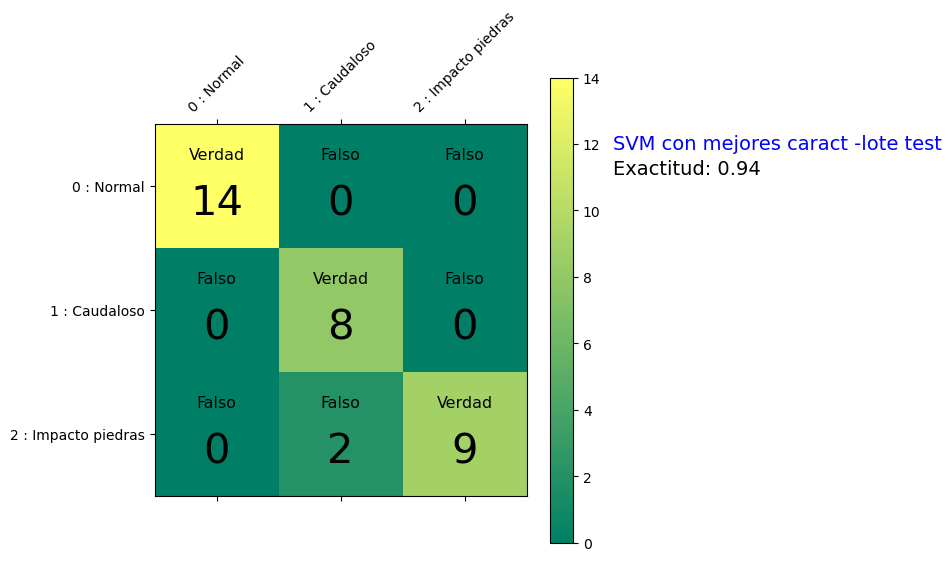

Indice Kappa SVM con  3  mejores caracteristicas -lote test: 0.907563025210084
-------clasificación SVM 3  mejores caract - sobre la totalidad de las observaciones--------
La precisión de la predicción es:  93.45794392523365 %


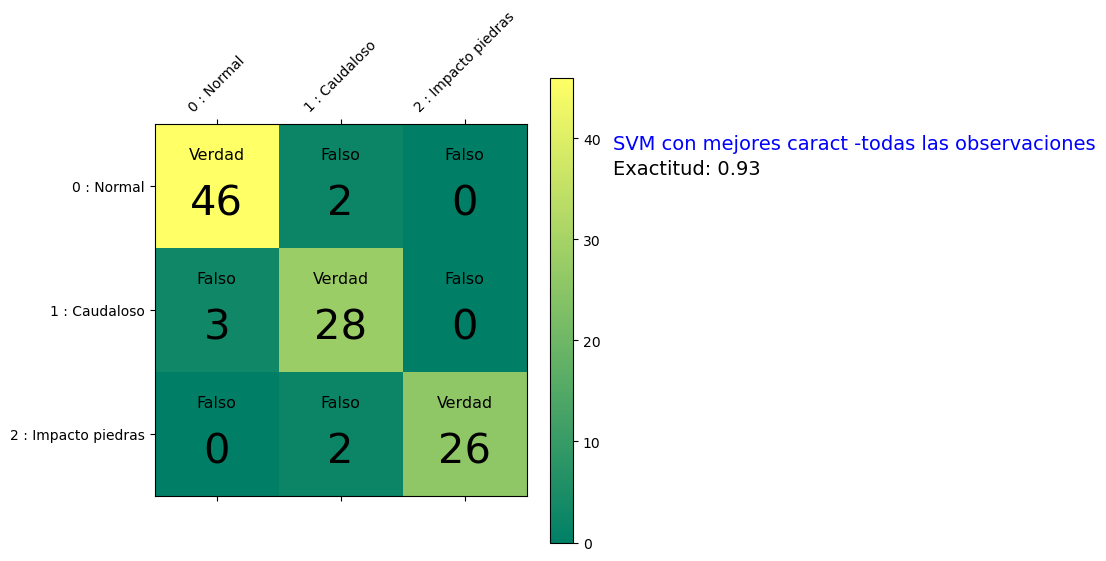

Indice Kappa SVM con mejores caract -todas las observaciones: 0.8984682120103022


In [33]:
# --- Una vez ajustado el modelo se puede utilizar para predecir nuevos valores.
print('-----------clasificación SVM ', num_mejor_carac,' mejores caract por modalidad - sobre el lote de test-----------------');
clase_prediccion=optimal_model.predict(x_test);
print("La precisión de la predicción es: ",optimal_model.score(x_test, y_test)*100,"%");
clase_test=y_test;
metricas_reg0=calcular_metricas(clase_test, clase_prediccion,2);
metricas_tabla=np.insert(metricas_tabla, 2, metricas_reg0, axis=0);#debe inciar desde 0 y luego se incrementa
parametros.append("4 carac,200 árboles");
matriz_de_confusion(y_test, clase_prediccion, "SVM con mejores caract -lote test") 
kappa1=cohen_kappa_score(y_test, clase_prediccion);
print('Indice Kappa SVM con ',num_mejor_carac,' mejores caracteristicas -lote test:',kappa1);

print('-------clasificación SVM',num_mejor_carac,' mejores caract - sobre la totalidad de las observaciones--------');
clase_prediccion=optimal_model.predict(x);
print("La precisión de la predicción es: ",optimal_model.score(x, y)*100,"%");
matriz_de_confusion(y, clase_prediccion, "SVM con mejores caract -todas las observaciones") 
kappa1=cohen_kappa_score(y, clase_prediccion);
print('Indice Kappa SVM con mejores caract -todas las observaciones:',kappa1);

<h1>Parte 3  - Elegir mejores características solo acústica</h1>

<h2> 5.1 Seleccionar las mejores características acusticas</h2>

In [61]:
num_mejor_carac=24;
print("Aplicando una función que selecciona las", num_mejor_carac ," mejores caracteristicas");
df = pd.read_csv('features_16agos2026_sismos_audio_unificado_csv.csv')
df.head(10) #muestra las 10 primeras filas

caracteristicas0= df.to_numpy();
caracteristicas1= caracteristicas0[:,3:48]; #la tercera posicion tiene la primer característica y se extiende hasta la columna (48-1)
# la columna sub0 tiene el experimento
clase= caracteristicas0[:,2]; # la segunda columna tiene la clase
print('-------preprocesando--------');
le = preprocessing.LabelEncoder();
le.fit(clase);
print(le);
print(le.classes_);
clase=le.transform(clase); #con esto se tranforman las etiquetas de numeros a categorias

select = SelectKBest(score_func=chi2, k=num_mejor_carac)
# scale the data to be between 0 and 1,  ya que chi2 solo soporta valores positivos
sc = MinMaxScaler()
caracteristicas_normal_pos = sc.fit_transform(caracteristicas1)
z_mejores_caract = select.fit_transform(caracteristicas_normal_pos,clase) #caracteristicas, clase
print("Después de seleccionar, las ",num_mejor_carac," mejores características, la matriz es de:", z_mejores_caract.shape) 

#print(z_mejores_caract);

filter = select.get_support()
# si agrega otras caracteristicas esto debe cambiar
features0=['c1','c2','c3','c4','c5','c6','c7','c8','c9','c10','c11','c12','c13','c14','c15','c16','c17','c18','c19','c20','c21','c22',
           'c23','c24','c25','c26','c27','c28','c29','c30','c31','c32','c33','c34','c35','c36','c37','c38','c39','c40','c41','c42','c43','c44',
         'c45'];

features=array(features0);
print();
print("Todas las caracteristicas:")
print(features)
print();

print("Las ",num_mejor_carac," mejores selecionadas:");
print(features[filter]);
print();
#print(z_mejores_caract); 
print(clase);


Aplicando una función que selecciona las 24  mejores caracteristicas
-------preprocesando--------
LabelEncoder()
[0 1 2]
Después de seleccionar, las  24  mejores características, la matriz es de: (107, 24)

Todas las caracteristicas:
['c1' 'c2' 'c3' 'c4' 'c5' 'c6' 'c7' 'c8' 'c9' 'c10' 'c11' 'c12' 'c13'
 'c14' 'c15' 'c16' 'c17' 'c18' 'c19' 'c20' 'c21' 'c22' 'c23' 'c24' 'c25'
 'c26' 'c27' 'c28' 'c29' 'c30' 'c31' 'c32' 'c33' 'c34' 'c35' 'c36' 'c37'
 'c38' 'c39' 'c40' 'c41' 'c42' 'c43' 'c44' 'c45']

Las  24  mejores selecionadas:
['c2' 'c4' 'c5' 'c7' 'c8' 'c10' 'c11' 'c12' 'c13' 'c14' 'c15' 'c16' 'c20'
 'c21' 'c23' 'c24' 'c26' 'c27' 'c28' 'c34' 'c35' 'c39' 'c41' 'c42']

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


<h2>5.2 Construir el conjunto de entrenamiento</h2>

In [62]:
x=z_mejores_caract;
print('-------preprocesando--------');
le = preprocessing.LabelEncoder();
le.fit(clase);
print(le);
print(le.classes_);
y=le.transform(clase); #con esto se tranforman las etiquetas de numeros a categorias
    
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=23)

-------preprocesando--------
LabelEncoder()
[0 1 2]


<h2>5.3 Módulo para optuna</h2>

In [63]:
def objective(trial):
       # Definition of space search
       C = trial.suggest_float("C", 1e-10, 1e10, log=True)
       gamma = trial.suggest_float("gamma", 1e-10, 1e10, log=True)
       kernel = trial.suggest_categorical("kernel", ["linear", "rbf", "poly"])
        
       # Classifier definition
       # Crear el modelo SVM con los parámetros sugeridos
       model = SVC(C=C, gamma=gamma, kernel=kernel)
    
       # Evaluar el modelo usando Validación Cruzada
       score = cross_val_score(model, x_train, y_train, n_jobs=-1, cv=3).mean()
    
       return score 

<h2>5.4 Entrenamiento</h2>

In [64]:
# 2. Crear un estudio de Optuna y especificar la dirección (maximizar la precisión)
study = optuna.create_study(direction='maximize')

# 3. Ejecutar la optimización
# Recevies the function to be optimized and the number of trials
study.optimize(objective, n_trials=500) #estaba en n_trials=20
	

[I 2026-08-17 16:20:50,441] A new study created in memory with name: no-name-971537a8-5387-4f9a-8e46-4ba7876c1f40
[I 2026-08-17 16:20:54,163] Trial 0 finished with value: 0.6222222222222222 and parameters: {'C': 852957528.3018928, 'gamma': 1857704791.1585355, 'kernel': 'linear'}. Best is trial 0 with value: 0.6222222222222222.
[I 2026-08-17 16:20:55,425] Trial 1 finished with value: 0.4594444444444444 and parameters: {'C': 4.079401291014328e-08, 'gamma': 4.40262499432769e-09, 'kernel': 'rbf'}. Best is trial 0 with value: 0.6222222222222222.
[I 2026-08-17 16:20:55,445] Trial 2 finished with value: 0.4594444444444444 and parameters: {'C': 7.923609050128849e-10, 'gamma': 0.005086542657225132, 'kernel': 'poly'}. Best is trial 0 with value: 0.6222222222222222.
[I 2026-08-17 16:20:55,471] Trial 3 finished with value: 0.5544444444444445 and parameters: {'C': 4413.044967506159, 'gamma': 0.03544761202972271, 'kernel': 'poly'}. Best is trial 0 with value: 0.6222222222222222.
[I 2026-08-17 16:20:

<h2>5.5 Resultado del modelo</h2>

In [65]:
# 4. Resultados del modelo
    
print(f"Número de ensayos terminados: {len(study.trials)}")
print(f"Best average accuracy: {study.best_value}")
print(f"Best parameters: {study.best_params}")
mejores_parametros=study.best_params
optimal_model=SVC(**mejores_parametros)
optimal_model.fit(x_train, y_train);
# Trains a model with the optimal parameters
#optimal_model = modelOpt.train_optimal_configuration(study.best_params)
#Print final results
print(f"Test score: {optimal_model.score(x_test, y_test)}")
print(f"Train score: {optimal_model.score(x_train, y_train)}")

Número de ensayos terminados: 500
Best average accuracy: 0.648888888888889
Best parameters: {'C': 350.63143768497184, 'gamma': 23434348.955362268, 'kernel': 'linear'}
Test score: 0.696969696969697
Train score: 0.9459459459459459


<h2>5.6 Matriz de confusión</h2>

---------clasificación SVM mejores caract - sobre el lote de test--------
La precisión de la predicción es:  69.6969696969697 %

Accuracy: 0.697

Loss: 0.303

f1_per_clase: 0.867 0.444 0.667

balanceado accuracy: 0.658

Sensitivity (Recall):0.929 0.500 0.545
[[13  1  0]
 [ 3  4  1]
 [ 0  5  6]]

Presición nor-cau-pie:0.929 0.500 0.545

Specificity nor-cau-pie:0.071 0.500 0.455

G-Mean:0.633

Cohen’s kappa:0.534


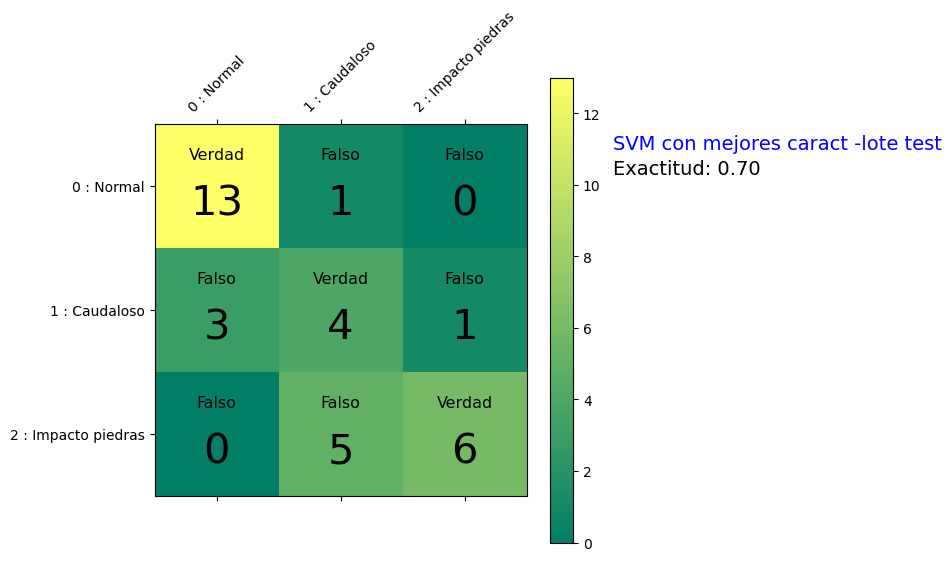

Indice Kappa SVM con  mejores características -lote test: 0.5338983050847457
--------clasificación SVM mejores caract - sobre la totalidad de las observaciones-------
La precisión de la predicción es:  86.91588785046729 %


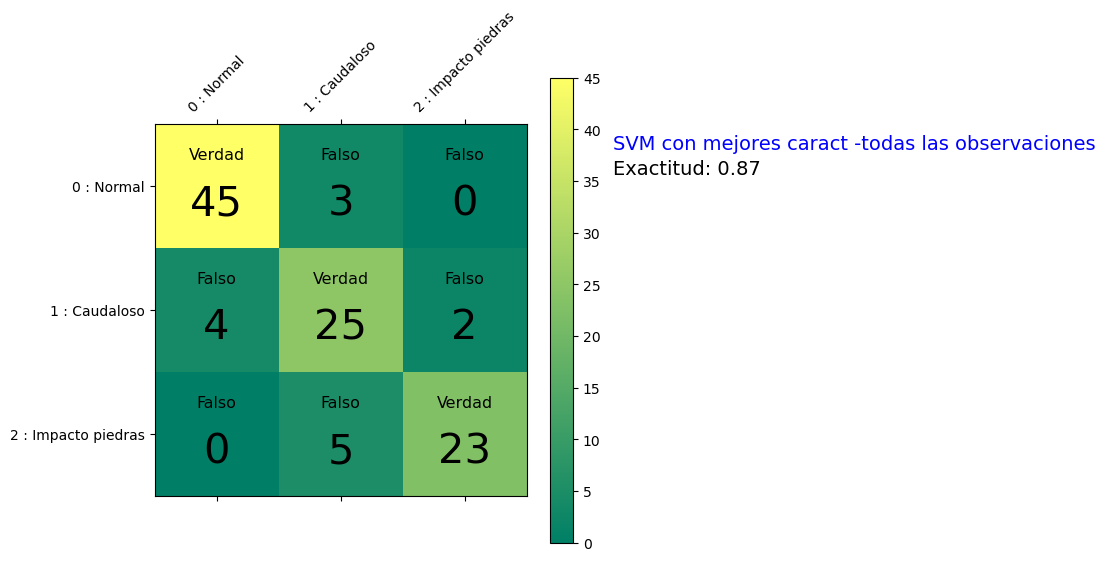

Indice Kappa SVM con mejores caract -todas las observaciones: 0.7968538106861948


In [66]:
# --- Una vez ajustado el modelo se puede utilizar para predecir nuevos valores.
print('---------clasificación SVM mejores caract - sobre el lote de test--------');
clase_prediccion=optimal_model.predict(x_test);
print("La precisión de la predicción es: ",optimal_model.score(x_test, y_test)*100,"%");
clase_test=y_test;
metricas_reg0=calcular_metricas(clase_test, clase_prediccion,2);
metricas_tabla=np.insert(metricas_tabla, 2, metricas_reg0, axis=0);#debe inciar desde 0 y luego se incrementa
parametros.append("4 carac,200 árboles");
matriz_de_confusion(y_test, clase_prediccion, "SVM con mejores caract -lote test") 
kappa1=cohen_kappa_score(y_test, clase_prediccion);
print('Indice Kappa SVM con  mejores características -lote test:',kappa1);

print('--------clasificación SVM mejores caract - sobre la totalidad de las observaciones-------');
clase_prediccion=optimal_model.predict(x);
print("La precisión de la predicción es: ",optimal_model.score(x, y)*100,"%");
matriz_de_confusion(y, clase_prediccion, "SVM con mejores caract -todas las observaciones") 
kappa1=cohen_kappa_score(y, clase_prediccion);
print('Indice Kappa SVM con mejores caract -todas las observaciones:',kappa1);


<h1>Parte 4  - Elegir mejores características solo microsismos</h1>

<h2> 6.1 Seleccionar las mejores características microsismos</h2>

In [55]:
num_mejor_carac=24
# si se trabaja con las tres caracteristicas propuestas se debe ubicar hasta la columna 79
# si no se desea las tres caracteristicas propuestas se debe ubicar hasta la columna (79-3)=76
caracteristicas2= caracteristicas0[:,48:75]; #la posicion 48 tiene la primer característica y se extiende hasta la columna (79-1)
#la posicion 48 tiene la primer característica y se extiende hasta la columna (78-3)
clase= caracteristicas0[:,2]; # la segunda columna tiene la clase
print('-------preprocesando--------');
le = preprocessing.LabelEncoder();
le.fit(clase);
print(le);
print(le.classes_);
clase=le.transform(clase); #con esto se tranforman las etiquetas de numeros a categorias

select2 = SelectKBest(score_func=chi2, k=num_mejor_carac)
# scale the data to be between 0 and 1,  ya que chi2 solo soporta valores positivos
sc = MinMaxScaler()
caracteristicas_normal_pos2 = sc.fit_transform(caracteristicas2)
z_mejores_caract2 = select2.fit_transform(caracteristicas_normal_pos2,clase) #caracteristicas, clase
print("Después de seleccionar, las ",num_mejor_carac," mejores caracteristicas, la matriz es de:", z_mejores_caract2.shape) 

filter2 = select2.get_support()
# si agrega otras caracteristicas esto debe cambiar

#lo siguiente si desea las 30 caracteristicas, incluyendo las tres propuestas
#features1=['f1','f2','f3','f4','f5','f6','f7','f8','f9','f10','f11','f12','f13','f14','f15','f16','f17','f18','f19','f20','f21','f22',
#           'f23','f24','f25','f26','f27','f28','f29','f30'];
#lo siguiente si desea 27 caracteristicas, sin incluir las tres propuestas
features1=['f1','f2','f3','f4','f5','f6','f7','f8','f9','f10','f11','f12','f13','f14','f15','f16','f17','f18','f19','f20','f21','f22',
           'f23','f24','f25','f26','f27'];

features2=array(features1);
print();
print("Todas las caracteristicas:")
print(features2)
print();

print("Las ",num_mejor_carac," mejores seleccionadas:");
print(features2[filter2]);
print();


-------preprocesando--------
LabelEncoder()
[0 1 2]
Después de seleccionar, las  24  mejores caracteristicas, la matriz es de: (107, 24)

Todas las caracteristicas:
['f1' 'f2' 'f3' 'f4' 'f5' 'f6' 'f7' 'f8' 'f9' 'f10' 'f11' 'f12' 'f13'
 'f14' 'f15' 'f16' 'f17' 'f18' 'f19' 'f20' 'f21' 'f22' 'f23' 'f24' 'f25'
 'f26' 'f27']

Las  24  mejores seleccionadas:
['f1' 'f2' 'f4' 'f5' 'f6' 'f7' 'f9' 'f10' 'f11' 'f12' 'f13' 'f14' 'f15'
 'f16' 'f17' 'f18' 'f19' 'f20' 'f21' 'f22' 'f23' 'f24' 'f25' 'f26']



<h2> 6.2 Construir el conjunto de entrenamiento</h2>

In [56]:
x=z_mejores_caract2;
print('-------preprocesando--------');
le = preprocessing.LabelEncoder();
le.fit(clase);
print(le);
print(le.classes_);
y=le.transform(clase); #con esto se tranforman las etiquetas de numeros a categorias
    
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=23)

-------preprocesando--------
LabelEncoder()
[0 1 2]


<h2> 6.3 Módulo para optuna</h2>

In [57]:
def objective(trial):
       # Definition of space search
       C = trial.suggest_float("C", 1e-10, 1e10, log=True)
       gamma = trial.suggest_float("gamma", 1e-10, 1e10, log=True)
       kernel = trial.suggest_categorical("kernel", ["linear", "rbf", "poly"])
        
       # Classifier definition
       # Crear el modelo SVM con los parámetros sugeridos
       model = SVC(C=C, gamma=gamma, kernel=kernel)
    
       # Evaluar el modelo usando Validación Cruzada
       score = cross_val_score(model, x_train, y_train, n_jobs=-1, cv=3).mean()
    
       return score 

<h2> 6.4 Entrenamiento</h2>

In [58]:
# 2. Crear un estudio de Optuna y especificar la dirección (maximizar la precisión)
study = optuna.create_study(direction='maximize')

# 3. Ejecutar la optimización
# Recevies the function to be optimized and the number of trials
study.optimize(objective, n_trials=500) #estaba en n_trials=20

[I 2026-08-17 16:08:43,366] A new study created in memory with name: no-name-4624a60f-68ab-4729-bb3a-5193dc9add36
[I 2026-08-17 16:08:47,557] Trial 0 finished with value: 0.8372222222222222 and parameters: {'C': 17271.85543779362, 'gamma': 0.03113939161110584, 'kernel': 'poly'}. Best is trial 0 with value: 0.8372222222222222.
[I 2026-08-17 16:08:48,765] Trial 1 finished with value: 0.8372222222222222 and parameters: {'C': 0.0006573540207302833, 'gamma': 22.70538269108023, 'kernel': 'poly'}. Best is trial 0 with value: 0.8372222222222222.
[I 2026-08-17 16:08:48,785] Trial 2 finished with value: 0.4594444444444444 and parameters: {'C': 8.863631014764567e-09, 'gamma': 9087788.03049606, 'kernel': 'linear'}. Best is trial 0 with value: 0.8372222222222222.
[I 2026-08-17 16:08:48,811] Trial 3 finished with value: 0.4594444444444444 and parameters: {'C': 340521.03805714793, 'gamma': 3.7284827412559105e-09, 'kernel': 'rbf'}. Best is trial 0 with value: 0.8372222222222222.
[I 2026-08-17 16:08:48

<h2> 6.5 Resultado del modelo</h2>

In [59]:
# 4. Resultados del modelo
    
print(f"Número de ensayos terminados: {len(study.trials)}")
print(f"Best average accuracy: {study.best_value}")
print(f"Best parameters: {study.best_params}")
mejores_parametros=study.best_params
optimal_model=SVC(**mejores_parametros)
optimal_model.fit(x_train, y_train);
# Trains a model with the optimal parameters
#optimal_model = modelOpt.train_optimal_configuration(study.best_params)
#Print final results
print(f"Test score: {optimal_model.score(x_test, y_test)}")
print(f"Train score: {optimal_model.score(x_train, y_train)}")

Número de ensayos terminados: 500
Best average accuracy: 0.8783333333333333
Best parameters: {'C': 11317.750913825208, 'gamma': 1.2032143615720268, 'kernel': 'rbf'}
Test score: 0.9393939393939394
Train score: 1.0


<h2> 6.6 Matriz de confusión</h2>

---------clasificación SVM mejores caract - sobre el lote de test--------
La precisión de la predicción es:  93.93939393939394 %

Accuracy: 0.939

Loss: 0.061

f1_per_clase: 0.963 0.889 0.952

balanceado accuracy: 0.946

Sensitivity (Recall):0.929 1.000 0.909
[[13  1  0]
 [ 0  8  0]
 [ 0  1 10]]

Presición nor-cau-pie:0.929 1.000 0.909

Specificity nor-cau-pie:0.071 0.000 0.091

G-Mean:0.945

Cohen’s kappa:0.908


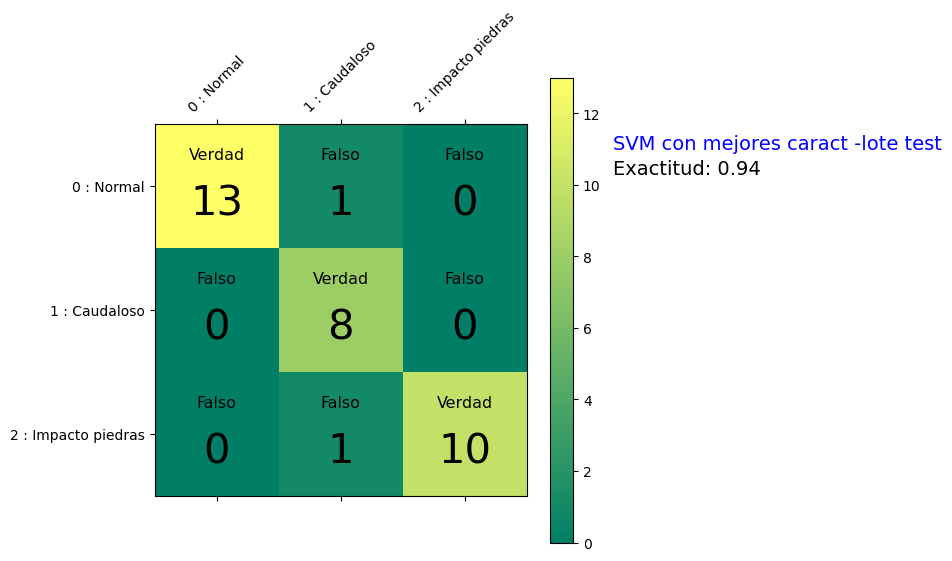

Indice Kappa SVM con  mejores características -lote test: 0.9079497907949791
--------clasificación SVM mejores caract - sobre la totalidad de las observaciones-------
La precisión de la predicción es:  98.13084112149532 %


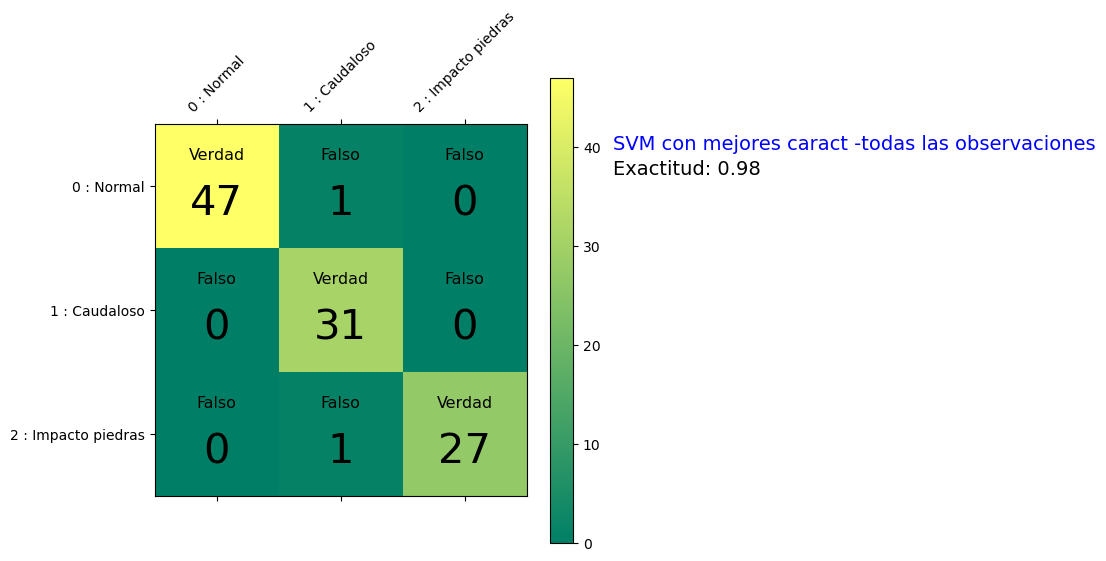

Indice Kappa SVM con mejores caract -todas las observaciones: 0.9711356892365794


In [60]:
# --- Una vez ajustado el modelo se puede utilizar para predecir nuevos valores.
print('---------clasificación SVM mejores caract - sobre el lote de test--------');
clase_prediccion=optimal_model.predict(x_test);
print("La precisión de la predicción es: ",optimal_model.score(x_test, y_test)*100,"%");
clase_test=y_test;
metricas_reg0=calcular_metricas(clase_test, clase_prediccion,2);
metricas_tabla=np.insert(metricas_tabla, 2, metricas_reg0, axis=0);#debe inciar desde 0 y luego se incrementa
parametros.append("4 carac,200 árboles");
matriz_de_confusion(y_test, clase_prediccion, "SVM con mejores caract -lote test") 
kappa1=cohen_kappa_score(y_test, clase_prediccion);
print('Indice Kappa SVM con  mejores características -lote test:',kappa1);

print('--------clasificación SVM mejores caract - sobre la totalidad de las observaciones-------');
clase_prediccion=optimal_model.predict(x);
print("La precisión de la predicción es: ",optimal_model.score(x, y)*100,"%");
matriz_de_confusion(y, clase_prediccion, "SVM con mejores caract -todas las observaciones") 
kappa1=cohen_kappa_score(y, clase_prediccion);
print('Indice Kappa SVM con mejores caract -todas las observaciones:',kappa1);
